In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df=pd.read_csv("cardekho_dataset.csv")
df
df.columns
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15411 entries, 0 to 15410
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Unnamed: 0         15411 non-null  int64  
 1   car_name           15411 non-null  object 
 2   brand              15411 non-null  object 
 3   model              15411 non-null  object 
 4   vehicle_age        15411 non-null  int64  
 5   km_driven          15411 non-null  int64  
 6   seller_type        15411 non-null  object 
 7   fuel_type          15411 non-null  object 
 8   transmission_type  15411 non-null  object 
 9   mileage            15411 non-null  float64
 10  engine             15411 non-null  int64  
 11  max_power          15411 non-null  float64
 12  seats              15411 non-null  int64  
 13  selling_price      15411 non-null  int64  
dtypes: float64(2), int64(6), object(6)
memory usage: 1.6+ MB


**Data Cleaning**


*   Handling Missing Values
*   Handling Duplicates


*   Check Datatype
*   Understand the dataset





In [30]:
#check  features with null values
df.isnull().sum()

Unnamed: 0           0
car_name             0
brand                0
model                0
vehicle_age          0
km_driven            0
seller_type          0
fuel_type            0
transmission_type    0
mileage              0
engine               0
max_power            0
seats                0
selling_price        0
dtype: int64

**Other Data Cleaning Steps**

In [31]:
#Handling Duplicates
df.duplicated().sum()

0

In [32]:
df=df.drop_duplicates()
df

,Unnamed: 0,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
0,0,Maruti Alto,Maruti,Alto,9,120000,Individual,Petrol,Manual,19.70,796,46.30,5,120000
1,1,Hyundai Grand,Hyundai,Grand,5,20000,Individual,Petrol,Manual,18.90,1197,82.00,5,550000
2,2,Hyundai i20,Hyundai,i20,11,60000,Individual,Petrol,Manual,17.00,1197,80.00,5,215000
3,3,Maruti Alto,Maruti,Alto,9,37000,Individual,Petrol,Manual,20.92,998,67.10,5,226000
4,4,Ford Ecosport,Ford,Ecosport,6,30000,Dealer,Diesel,Manual,22.77,1498,98.59,5,570000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15406,19537,Hyundai i10,Hyundai,i10,9,10723,Dealer,Petrol,Manual,19.81,1086,68.05,5,250000
15407,19540,Maruti Ertiga,Maruti,Ertiga,2,18000,Dealer,Petrol,Manual,17.50,1373,91.10,7,925000
15408,19541,Skoda Rapid,Skoda,Rapid,6,67000,Dealer,Diesel,Manual,21.14,1498,103.52,5,425000
15409,19542,Mahindra XUV500,Mahindra,XUV500,5,3800000,Dealer,Diesel,Manual,16.00,2179,140.00,7,1225000


In [33]:
df.duplicated().sum()

0

**Feature Engineering**

In [34]:
df.loc[df['brand']=='Ferrari']

,Unnamed: 0,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
3799,4845,Ferrari GTC4Lusso,Ferrari,GTC4Lusso,2,3800,Dealer,Petrol,Automatic,4.0,3855,601.0,4,39500000


Remove brand and model because it's information is in car_name column and Unnamed column also drop because it is not important.

In [35]:
df.drop(['brand','model','Unnamed: 0'],axis=1,inplace=True)
df

,car_name,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
0,Maruti Alto,9,120000,Individual,Petrol,Manual,19.70,796,46.30,5,120000
1,Hyundai Grand,5,20000,Individual,Petrol,Manual,18.90,1197,82.00,5,550000
2,Hyundai i20,11,60000,Individual,Petrol,Manual,17.00,1197,80.00,5,215000
3,Maruti Alto,9,37000,Individual,Petrol,Manual,20.92,998,67.10,5,226000
4,Ford Ecosport,6,30000,Dealer,Diesel,Manual,22.77,1498,98.59,5,570000
...,...,...,...,...,...,...,...,...,...,...,...
15406,Hyundai i10,9,10723,Dealer,Petrol,Manual,19.81,1086,68.05,5,250000
15407,Maruti Ertiga,2,18000,Dealer,Petrol,Manual,17.50,1373,91.10,7,925000
15408,Skoda Rapid,6,67000,Dealer,Diesel,Manual,21.14,1498,103.52,5,425000
15409,Mahindra XUV500,5,3800000,Dealer,Diesel,Manual,16.00,2179,140.00,7,1225000


**Type of Features**

Numeric Features

In [36]:
numeric_features=df.select_dtypes(exclude='object')
numeric_features

,vehicle_age,km_driven,mileage,engine,max_power,seats,selling_price
0,9,120000,19.70,796,46.30,5,120000
1,5,20000,18.90,1197,82.00,5,550000
2,11,60000,17.00,1197,80.00,5,215000
3,9,37000,20.92,998,67.10,5,226000
4,6,30000,22.77,1498,98.59,5,570000
...,...,...,...,...,...,...,...
15406,9,10723,19.81,1086,68.05,5,250000
15407,2,18000,17.50,1373,91.10,7,925000
15408,6,67000,21.14,1498,103.52,5,425000
15409,5,3800000,16.00,2179,140.00,7,1225000


Categorical Features

In [37]:
categorical_features=df.select_dtypes(include='object')
categorical_features

,car_name,seller_type,fuel_type,transmission_type
0,Maruti Alto,Individual,Petrol,Manual
1,Hyundai Grand,Individual,Petrol,Manual
2,Hyundai i20,Individual,Petrol,Manual
3,Maruti Alto,Individual,Petrol,Manual
4,Ford Ecosport,Dealer,Diesel,Manual
...,...,...,...,...
15406,Hyundai i10,Dealer,Petrol,Manual
15407,Maruti Ertiga,Dealer,Petrol,Manual
15408,Skoda Rapid,Dealer,Diesel,Manual
15409,Mahindra XUV500,Dealer,Diesel,Manual


Discrete Features

In [38]:
discrete_features=numeric_features.select_dtypes(include='int64')
discrete_features

,vehicle_age,km_driven,engine,seats,selling_price
0,9,120000,796,5,120000
1,5,20000,1197,5,550000
2,11,60000,1197,5,215000
3,9,37000,998,5,226000
4,6,30000,1498,5,570000
...,...,...,...,...,...
15406,9,10723,1086,5,250000
15407,2,18000,1373,7,925000
15408,6,67000,1498,5,425000
15409,5,3800000,2179,7,1225000


Continuous Features

In [39]:
continuous_features=numeric_features.select_dtypes(include='float64')
continuous_features

,mileage,max_power
0,19.70,46.30
1,18.90,82.00
2,17.00,80.00
3,20.92,67.10
4,22.77,98.59
...,...,...
15406,19.81,68.05
15407,17.50,91.10
15408,21.14,103.52
15409,16.00,140.00


Multicollinearity Check

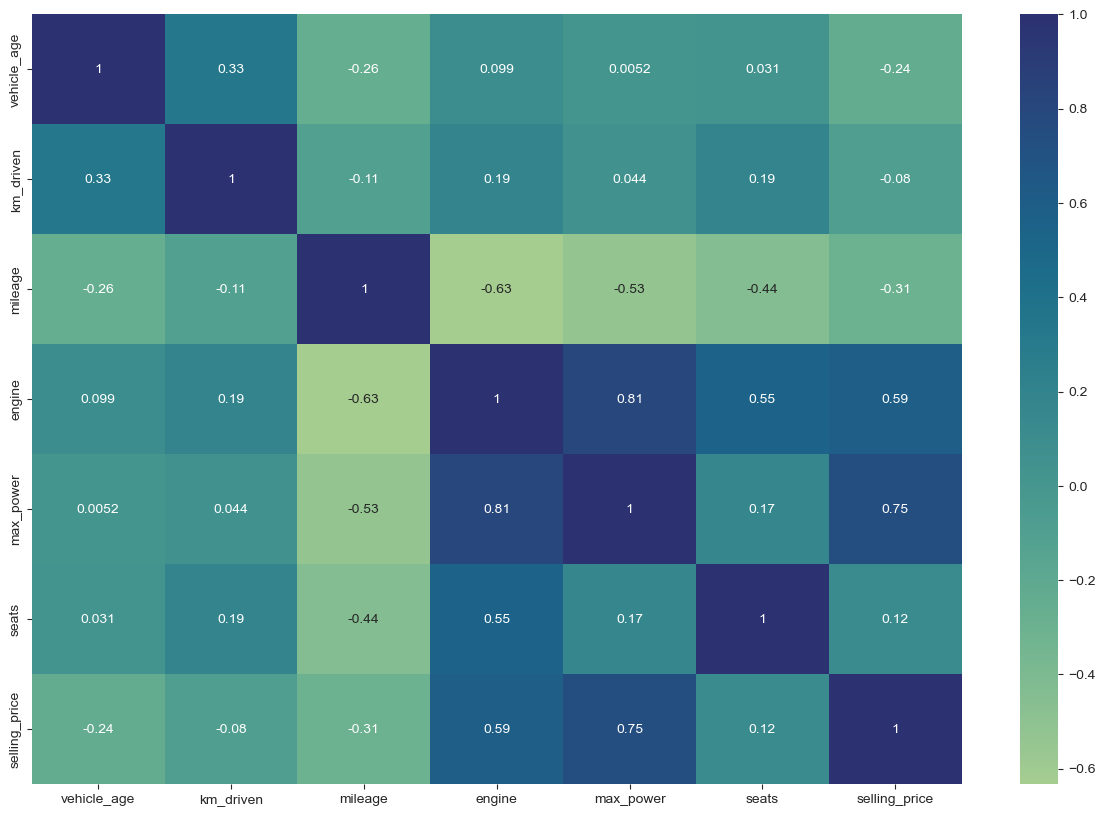

In [40]:
#Correlation Heatmap
df_corr=df.drop(columns=['car_name','seller_type','fuel_type','transmission_type'],axis=1).corr()
plt.figure(figsize=(15,10))
sns.heatmap(df_corr,cmap="crest",annot=True)
plt.show()

**Report**


*   Max power and Engine cc are highly correlated.
*   WE can check VIF to remove any highly correlated independent features.

Variance Inflation Factor(VIF)



*   Multicollinearity occurs when there are  two or more independent variables in a multiple regression model,which have a high correlation among themselves.when some features are highly correlated.
*   Multicollindearity can be detected using various techniques, one such technique being the varience Inflation Factor(VIF).






In [41]:
import statsmodels.api as sm
num_features=df.select_dtypes(exclude='object').columns
for i in range(0,len(num_features)-1):
  x=df.loc[:,df.columns==num_features[i]]
  y=df.selling_price
  model=sm.OLS(x,y)
  results=model.fit()
  rsq=results.rsquared
  vif=round(1/(1-rsq),2)
  print("Variance Inflation Factor of {} column is {}\n".format(num_features[i],vif))

Variance Inflation Factor of vehicle_age column is 1.34

Variance Inflation Factor of km_driven column is 1.24

Variance Inflation Factor of mileage column is 1.54

Variance Inflation Factor of engine column is 2.41

Variance Inflation Factor of max_power column is 3.13

Variance Inflation Factor of seats column is 1.77



If VIF is above 5 then we have to remove that column

**This dataset have multicollinearity in max_power column but not so much.**
- Max power and Engine are correlated but we can consider these two features because they hold important information for a vehicle.

Check Outlier and Capping it

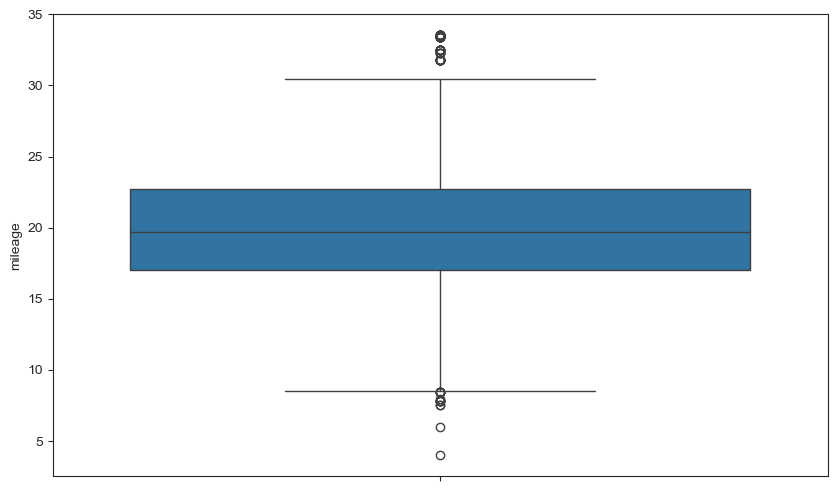

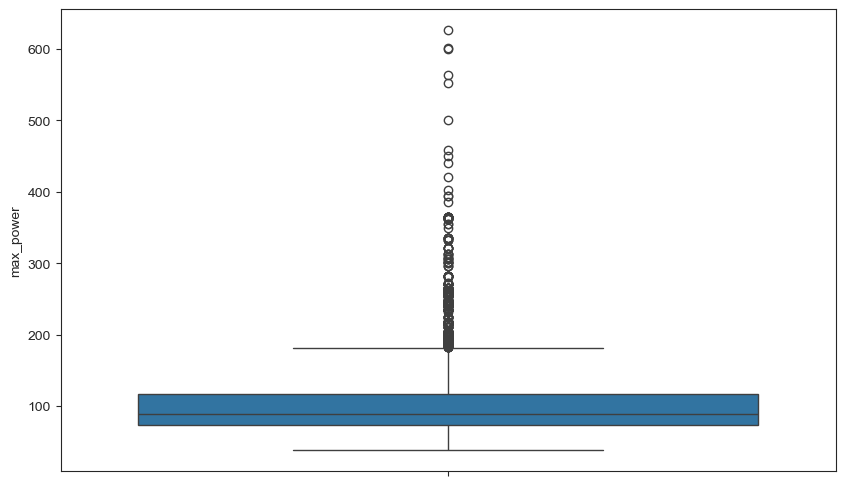

In [42]:
for i in continuous_features:
  plt.figure(figsize=(10,6))
  sns.set_style('ticks')
  ax=sns.boxplot(df[i])

Feature Transformation

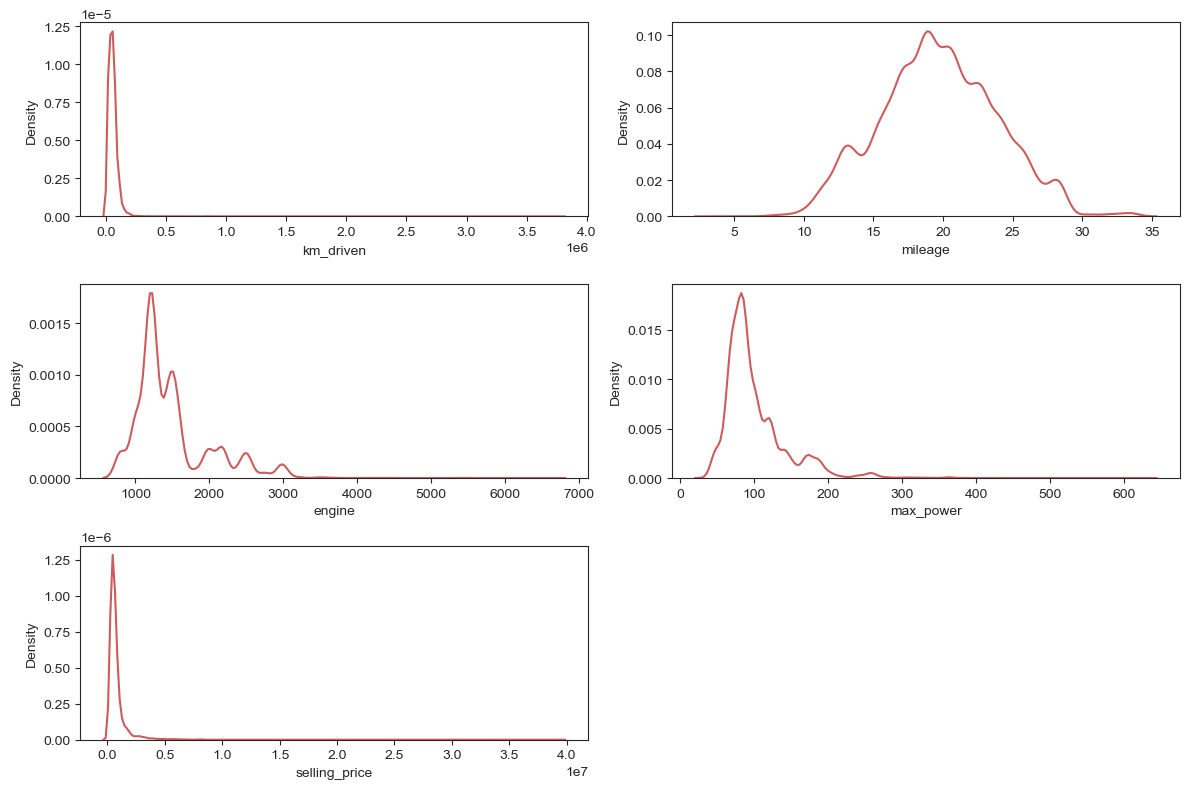

In [43]:
#distribution of data before scaling
plt.figure(figsize=(12,8))
for i,col in enumerate(['km_driven','mileage','engine','max_power','selling_price']):
  plt.subplot(3,2,i+1)
  sns.kdeplot(x=df[col],color='indianred')
  plt.xlabel(col)
  plt.tight_layout()

**Report**

After Capping Outlier it is all column's distribution is Normal so transformation is not required.

Split X and Y

In [44]:
from sklearn.model_selection import train_test_split
x=df.drop(['selling_price'],axis=1)
y=df['selling_price']

**Split Dataframe to x and y.**

**Here we set a variable x i.e independent columns and a variable y i.e. dependent columns as the 'selling_price' column**

Feature Selection

In [45]:
for feature in categorical_features:
  print(feature," : ",x[feature].nunique())

car_name  :  121
seller_type  :  3
fuel_type  :  5
transmission_type  :  2


**Feature Encoding and Scaling**

**one Hot Encoding for columns which had lesser unique values and not ordinal**


*   One hot encoding is a process by which categorical variables are converted into a form that could be provided to ML algorithms to do a better job in prediction.

**Binary Encoder**

*   To fight the curse of dimensionality, binary encoding might be a good alternative to one-hot encoding because it creates fewer columns when encoding categorical variables.

In [46]:
#create column transformer with 3 types of transformers
from sklearn.preprocessing import OneHotEncoder, StandardScaler, OrdinalEncoder
from sklearn.compose import ColumnTransformer

num_features = x.select_dtypes(exclude="object").columns
onehot_columns = ['seller_type', 'fuel_type', 'transmission_type']
label_columns = ['car_name']

numeric_transformer = StandardScaler()
oh_transformer = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
label_transformer = OrdinalEncoder()

preprocessor = ColumnTransformer(
    transformers=[
        ('onehot', oh_transformer, onehot_columns),
        ('label', label_transformer, label_columns),
        ('num', numeric_transformer, num_features)
    ]
)


In [47]:
x=preprocessor.fit_transform(x)

**Train Test Split**
- the train test split procedure is used to estimate the performance of ml algorithms when they are used to make predictions on data not used to train the model.
- It is a fast and easy procedure to perform, the results of which allow you to compare the performance of ml algorithms.

In [48]:
#separate dataset into train and test
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)
x_train.shape,x_test.shape

((12328, 17), (3083, 17))

**Model Selection**
- Here should understand the various regression models with default values from these models we can choose top 4 with highest accuracy score and proceed with HyperParameter tuning.

In [49]:
from sklearn.metrics import mean_squared_error,r2_score
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression,Ridge,Lasso
from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error

In [50]:
#create a function to evaluate model
def evaluate_model(true,predicted):
  mae=mean_absolute_error(true,predicted)
  mse=mean_squared_error(true,predicted)
  rmse=np.sqrt(mean_squared_error(true,predicted))
  r2_square=r2_score(true,predicted)
  return mae,rmse,r2_square

In [51]:
models={"Linear Regression" : LinearRegression(),
        "Lasso":Lasso(),
        "Ridge":Ridge(),
        "Decision Tree":DecisionTreeRegressor(),
        "Random Forest Regressior":RandomForestRegressor()
        }
model_list=[]
r2_list=[]

for i in range(len(list(models))):
  model=list(models.values())[i]
  model.fit(x_train,y_train) # train model

  #make predictions
  y_train_pred=model.predict(x_train)
  y_test_pred=model.predict(x_test)

  #evaluate train and test dataset
  model_train_mae,model_train_rmse,model_train_r2=evaluate_model(y_train,y_train_pred)
  model_test_mae,model_test_rmse,model_test_r2=evaluate_model(y_test,y_test_pred)

  print(list(models.keys())[i])
  model_list.append(list(models.keys())[i])

  print("Model performance for Training set")
  print("- Root Mean Squared Error: {:.4f}".format(model_train_rmse))
  print("- Mean Absolute Error: {:.4f}".format(model_train_mae))
  print("- R2 Score: {:.4f}".format(model_train_r2))

  print("--------------------------------------------")
  print("Model performance for Test set")
  print("- Root Mean Squared Error: {:.4f}".format(model_test_rmse))
  print("- Mean Absolute Error: {:.4f}".format(model_test_mae))
  print("- R2 Score: {:.4f}".format(model_test_r2))
  r2_list.append(model_test_r2)
  print("="*35)
  print("\n")


Linear Regression
Model performance for Training set
- Root Mean Squared Error: 553987.1288
- Mean Absolute Error: 266401.8012
- R2 Score: 0.6216
--------------------------------------------
Model performance for Test set
- Root Mean Squared Error: 501970.3511
- Mean Absolute Error: 277497.6562
- R2 Score: 0.6653


Lasso
Model performance for Training set
- Root Mean Squared Error: 553987.1331
- Mean Absolute Error: 266399.7183
- R2 Score: 0.6216
--------------------------------------------
Model performance for Test set
- Root Mean Squared Error: 501969.5181
- Mean Absolute Error: 277494.0500
- R2 Score: 0.6653


Ridge
Model performance for Training set
- Root Mean Squared Error: 553987.8042
- Mean Absolute Error: 266365.2036
- R2 Score: 0.6216
--------------------------------------------
Model performance for Test set
- Root Mean Squared Error: 501960.8356
- Mean Absolute Error: 277439.9549
- R2 Score: 0.6653


Decision Tree
Model performance for Training set
- Root Mean Squared Erro

In [52]:
pd.DataFrame(list(zip(model_list,r2_list)),columns=['Model Name','R2_Score']).sort_values(by=["R2_Score"],ascending=False)

,Model Name,R2_Score
4,Random Forest Regressior,0.936338
3,Decision Tree,0.883400
2,Ridge,0.665289
1,Lasso,0.665277
0,Linear Regression,0.665276
